In [3]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

DATA_PATH = 'P_2_StudentPerformanceFactors.csv'
df = pd.read_csv(DATA_PATH)
df.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


In [4]:
print('Shape:', df.shape)
display(df.info())
display(df.describe(include='all').T)
print('Missing values:\n', df.isna().sum())
print('Duplicate rows:', df.duplicated().sum())

Shape: (6607, 20)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Hours_Studied               6607 non-null   int64 
 1   Attendance                  6607 non-null   int64 
 2   Parental_Involvement        6607 non-null   object
 3   Access_to_Resources         6607 non-null   object
 4   Extracurricular_Activities  6607 non-null   object
 5   Sleep_Hours                 6607 non-null   int64 
 6   Previous_Scores             6607 non-null   int64 
 7   Motivation_Level            6607 non-null   object
 8   Internet_Access             6607 non-null   object
 9   Tutoring_Sessions           6607 non-null   int64 
 10  Family_Income               6607 non-null   object
 11  Teacher_Quality             6529 non-null   object
 12  School_Type                 6607 non-null   object
 13  Peer_Influence              66

None

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Hours_Studied,6607.0,NaN,NaN,NaN,19.975329,5.990594,1.0,16.0,20.0,24.0,44.0
Attendance,6607.0,NaN,NaN,NaN,79.977448,11.547475,60.0,70.0,80.0,90.0,100.0
Parental_Involvement,6607,3,Medium,3362,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Access_to_Resources,6607,3,Medium,3319,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Extracurricular_Activities,6607,2,Yes,3938,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Sleep_Hours,6607.0,NaN,NaN,NaN,7.02906,1.46812,4.0,6.0,7.0,8.0,10.0
Previous_Scores,6607.0,NaN,NaN,NaN,75.070531,14.399784,50.0,63.0,75.0,88.0,100.0
Motivation_Level,6607,3,Medium,3351,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Internet_Access,6607,2,Yes,6108,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Tutoring_Sessions,6607.0,NaN,NaN,NaN,1.493719,1.23057,0.0,1.0,1.0,2.0,8.0


Missing values:
 Hours_Studied                  0
Attendance                     0
Parental_Involvement           0
Access_to_Resources            0
Extracurricular_Activities     0
Sleep_Hours                    0
Previous_Scores                0
Motivation_Level               0
Internet_Access                0
Tutoring_Sessions              0
Family_Income                  0
Teacher_Quality               78
School_Type                    0
Peer_Influence                 0
Physical_Activity              0
Learning_Disabilities          0
Parental_Education_Level      90
Distance_from_Home            67
Gender                         0
Exam_Score                     0
dtype: int64
Duplicate rows: 0


In [18]:

# Remove duplicate rows
df = df.drop_duplicates()

# Fill missing numerical values with median
num_cols = df.select_dtypes(include=np.number).columns

for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

# Fill missing categorical values with mode
cat_cols = df.select_dtypes(include="object").columns

for col in cat_cols:
    if df[col].isnull().any():
        df[col] = df[col].fillna(df[col].mode()[0])

# Check cleaned data
print("Missing Values After Cleaning:")
print(df.isnull().sum().sum())

print("Final Shape:", df.shape)

Missing Values After Cleaning:
0
Final Shape: (6607, 20)


In [19]:

# Remove duplicate rows
df = df.drop_duplicates()

# Fill missing numerical values with median
num_cols = df.select_dtypes(include=np.number).columns

for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

# Fill missing categorical values with mode
cat_cols = df.select_dtypes(include="object").columns

for col in cat_cols:
    if df[col].isnull().any():
        df[col] = df[col].fillna(df[col].mode()[0])

# Check cleaned data
print("Missing Values After Cleaning:")
print(df.isnull().sum().sum())

print("Final Shape:", df.shape)

Missing Values After Cleaning:
0
Final Shape: (6607, 20)


In [5]:
target='Exam_Score'
X=df.drop(columns=[target]); y=df[target]
num_cols=X.select_dtypes(include=np.number).columns.tolist()
cat_cols=X.select_dtypes(exclude=np.number).columns.tolist()
print('Numeric:', num_cols)
print('Categorical:', cat_cols)
print('Target summary:\n', y.describe())

Numeric: ['Hours_Studied', 'Attendance', 'Sleep_Hours', 'Previous_Scores', 'Tutoring_Sessions', 'Physical_Activity']
Categorical: ['Parental_Involvement', 'Access_to_Resources', 'Extracurricular_Activities', 'Motivation_Level', 'Internet_Access', 'Family_Income', 'Teacher_Quality', 'School_Type', 'Peer_Influence', 'Learning_Disabilities', 'Parental_Education_Level', 'Distance_from_Home', 'Gender']
Target summary:
 count    6607.000000
mean       67.235659
std         3.890456
min        55.000000
25%        65.000000
50%        67.000000
75%        69.000000
max       101.000000
Name: Exam_Score, dtype: float64


In [20]:
# Define target and input features
X = df.drop(columns=["Exam_Score"])
y = df["Exam_Score"]

# Identify numerical and categorical columns
numeric_features = X.select_dtypes(include=np.number).columns
categorical_features = X.select_dtypes(
    include=["object", "category"]
).columns

# Preprocessing pipeline
preprocessor = ColumnTransformer([
    ("num", SimpleImputer(strategy="median"),
     numeric_features),

    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ]), categorical_features)
])

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (5285, 19)
Testing Data: (1322, 19)


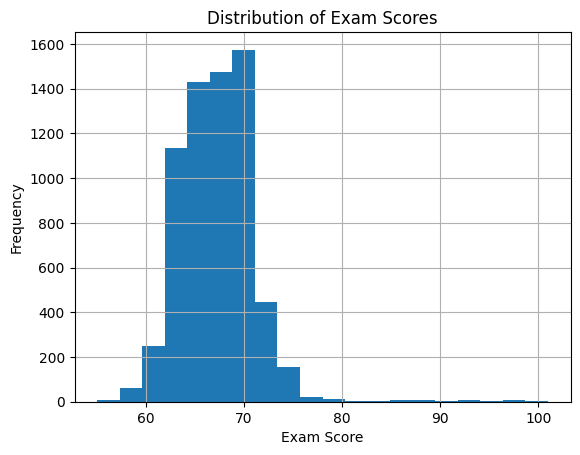

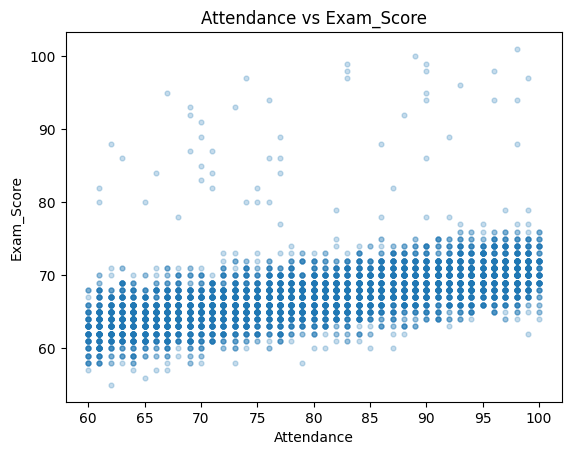

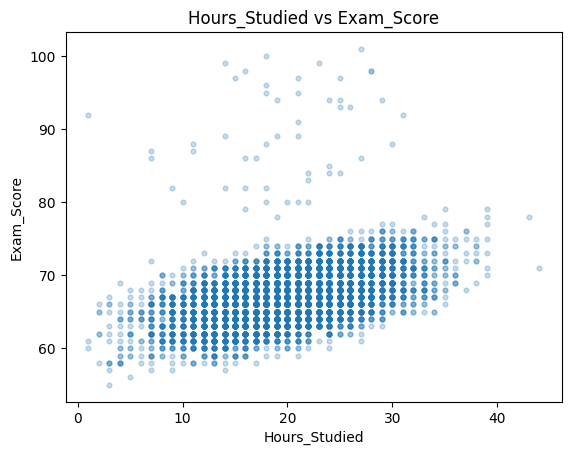

,count,mean,median,std
Motivation_Level,,,,
High,1319,67.704321,67.0,3.876966
Medium,3351,67.330648,67.0,3.827303
Low,1937,66.752194,67.0,3.958139


,count,mean,median
Parental_Involvement,,,
High,1908,68.092767,68.0
Medium,3362,67.098156,67.0
Low,1337,66.358265,66.0


,Exam_Score
Exam_Score,1.000000
Attendance,0.581072
Hours_Studied,0.445455
Previous_Scores,0.175079
Tutoring_Sessions,0.156525
Physical_Activity,0.027824
Sleep_Hours,-0.017022


In [6]:
fig, ax = plt.subplots(); y.hist(bins=20, ax=ax); ax.set(title='Distribution of Exam Scores', xlabel='Exam Score', ylabel='Frequency'); plt.show()
for col in ['Attendance','Hours_Studied']:
    plt.figure(); plt.scatter(df[col], y, alpha=.25, s=12); plt.xlabel(col); plt.ylabel(target); plt.title(f'{col} vs {target}'); plt.show()
display(df.groupby('Motivation_Level', dropna=False)[target].agg(['count','mean','median','std']).sort_values('mean',ascending=False))
display(df.groupby('Parental_Involvement', dropna=False)[target].agg(['count','mean','median']).sort_values('mean',ascending=False))
display(df[num_cols+[target]].corr()[target].sort_values(ascending=False))

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)
def make_preprocessor(scale=False):
    numeric_steps=[('imputer', SimpleImputer(strategy='median'))]
    if scale: numeric_steps.append(('scaler', StandardScaler()))
    return ColumnTransformer([
        ('num', Pipeline(numeric_steps), num_cols),
        ('cat', Pipeline([('imputer', SimpleImputer(strategy='most_frequent')), ('onehot', OneHotEncoder(handle_unknown='ignore'))]), cat_cols)
    ])
models={
 'Linear Regression': Pipeline([('prep',make_preprocessor(True)),('model',LinearRegression())]),
 'Ridge Regression': Pipeline([('prep',make_preprocessor(True)),('model',Ridge(alpha=1.0))]),
 'Random Forest': Pipeline([('prep',make_preprocessor(False)),('model',RandomForestRegressor(n_estimators=250,random_state=42,n_jobs=-1,min_samples_leaf=2))]),
 'Extra Trees': Pipeline([('prep',make_preprocessor(False)),('model',ExtraTreesRegressor(n_estimators=250,random_state=42,n_jobs=-1,min_samples_leaf=2))])
}
rows=[]
for name, model in models.items():
    model.fit(X_train,y_train)
    pred=model.predict(X_test)
    rows.append({'Model':name,'MAE':mean_absolute_error(y_test,pred),'RMSE':mean_squared_error(y_test,pred)**0.5,'R2':r2_score(y_test,pred)})
results=pd.DataFrame(rows).sort_values('RMSE')
display(results)
best_name=results.iloc[0]['Model']; best_model=models[best_name]; y_pred=best_model.predict(X_test)
print('Selected by lowest holdout RMSE:',best_name)

,Model,MAE,RMSE,R2
1,Ridge Regression,0.452371,1.804410,0.769658
0,Linear Regression,0.452392,1.804445,0.769650
3,Extra Trees,0.983475,2.039487,0.705731
2,Random Forest,1.053712,2.117055,0.682922


Selected by lowest holdout RMSE: Ridge Regression


In [9]:

numeric_df = df.select_dtypes(include=np.number)

# Calculate Pearson correlation
correlation_matrix = numeric_df.corr()

# Display correlation values
display(correlation_matrix.round(2))

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
Hours_Studied,1.00,-0.01,0.01,0.02,-0.01,0.00,0.45
Attendance,-0.01,1.00,-0.02,-0.02,0.01,-0.02,0.58
Sleep_Hours,0.01,-0.02,1.00,-0.02,-0.01,-0.00,-0.02
Previous_Scores,0.02,-0.02,-0.02,1.00,-0.01,-0.01,0.18
Tutoring_Sessions,-0.01,0.01,-0.01,-0.01,1.00,0.02,0.16
Physical_Activity,0.00,-0.02,-0.00,-0.01,0.02,1.00,0.03
Exam_Score,0.45,0.58,-0.02,0.18,0.16,0.03,1.00


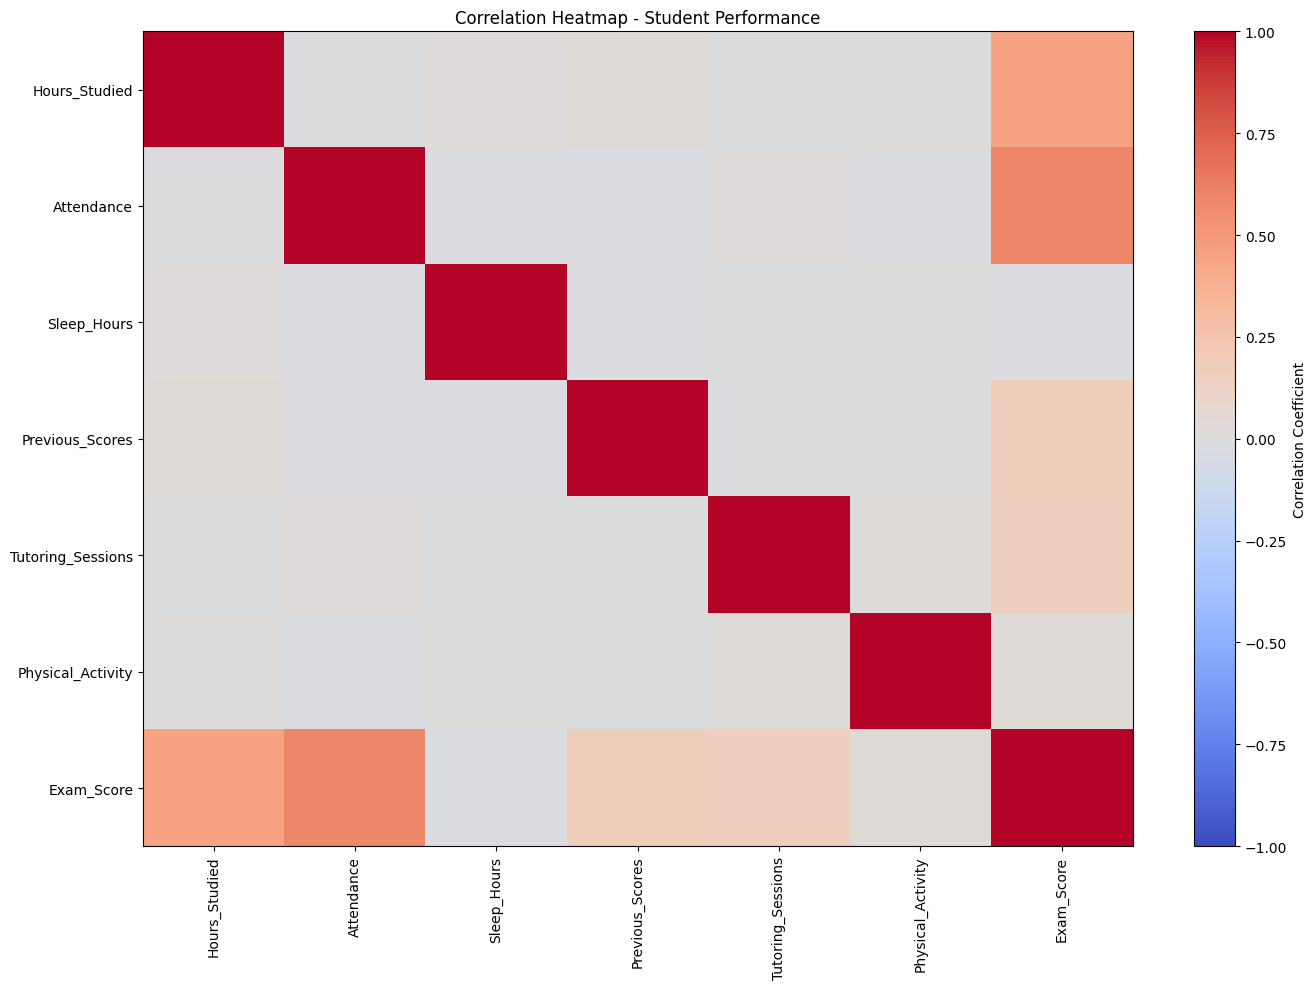

In [10]:

# Plot correlation heatmap

plt.figure(figsize=(14, 10))

plt.imshow(correlation_matrix, cmap='coolwarm',
           vmin=-1, vmax=1, aspect='auto')

plt.colorbar(label='Correlation Coefficient')

plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=90
)

plt.yticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns
)

plt.title('Correlation Heatmap - Student Performance')
plt.tight_layout()
plt.show()

In [11]:

# Correlation of all numerical features with Exam_Score

exam_corr = correlation_matrix['Exam_Score'].drop(
    'Exam_Score'
).sort_values(ascending=False)

display(exam_corr.to_frame(name='Correlation with Exam_Score'))

,Correlation with Exam_Score
Attendance,0.581072
Hours_Studied,0.445455
Previous_Scores,0.175079
Tutoring_Sessions,0.156525
Physical_Activity,0.027824
Sleep_Hours,-0.017022


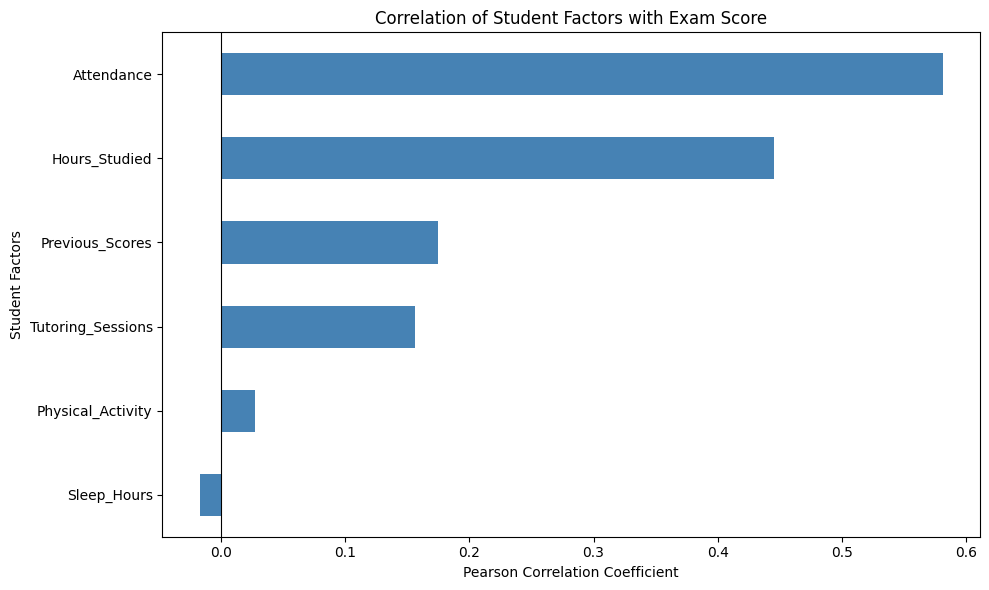

In [12]:

plt.figure(figsize=(10, 6))

exam_corr.sort_values().plot(
    kind='barh',
    color='steelblue'
)

plt.axvline(0, color='black', linewidth=0.8)
plt.title('Correlation of Student Factors with Exam Score')
plt.xlabel('Pearson Correlation Coefficient')
plt.ylabel('Student Factors')
plt.tight_layout()
plt.show()

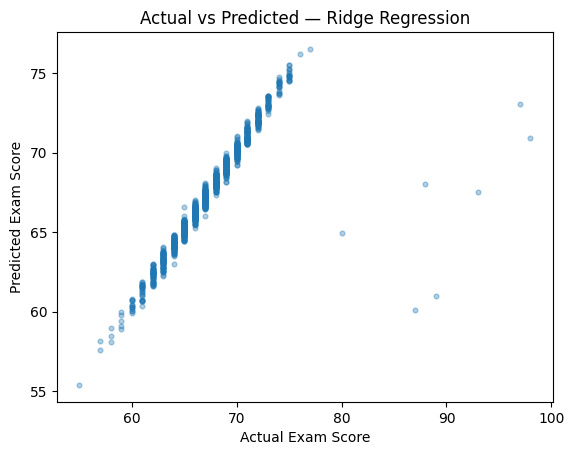

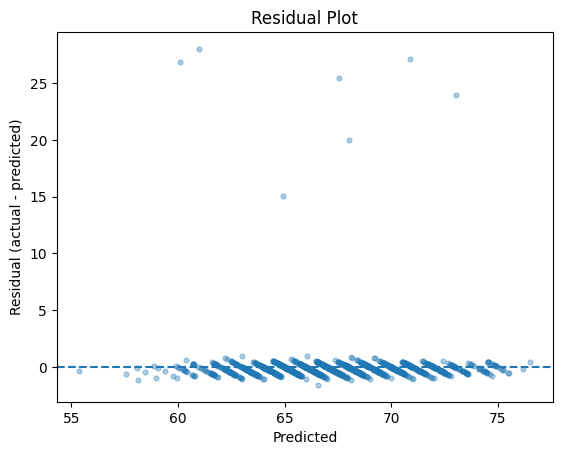

Test MAE: 0.452370684338194
Test RMSE: 1.8044096869031667
Test R2: 0.7696584630608467


In [8]:
plt.figure(); plt.scatter(y_test,y_pred,alpha=.35,s=12); plt.xlabel('Actual Exam Score'); plt.ylabel('Predicted Exam Score'); plt.title(f'Actual vs Predicted — {best_name}'); plt.show()
residuals=y_test-y_pred
plt.figure(); plt.scatter(y_pred,residuals,alpha=.35,s=12); plt.axhline(0,linestyle='--'); plt.xlabel('Predicted'); plt.ylabel('Residual (actual - predicted)'); plt.title('Residual Plot'); plt.show()
print('Test MAE:', mean_absolute_error(y_test,y_pred))
print('Test RMSE:', mean_squared_error(y_test,y_pred)**0.5)
print('Test R2:', r2_score(y_test,y_pred))

In [17]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Separate features and target
X = df.drop("Exam_Score", axis=1)
y = df["Exam_Score"]

# Identify numerical and categorical columns
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns
categorical_features = X.select_dtypes(include=["object"]).columns

# Preprocessing for numerical data
numeric_transformer = SimpleImputer(strategy="median")

# Preprocessing for categorical data
categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

# Combine preprocessing steps
preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])